# Experiments 2 & 3 — LQR v21/v22 Simulation
LQR vs Ratio Baseline vs 50:50 Baseline  |  Kalman filter  |  2 hours

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

A_D = np.array([
    [0.99930577, -0.00002068, -0.00003493],
    [0.00233387,  0.98443635,  0.02453758],
    [-0.00015568,  0.00111512,  0.99805077]
])
B_D = np.array([
    [0.0,          1.80650e-03],
    [6.84417e-04, -4.73295e-03],
    [2.49130e-02, -1.66300e-03],
])
VFA0, EC0, PH0 = 50.25, 10.0, 7.2
x_sp  = np.array([VFA0, EC0, PH0])
u_bl  = np.array([0.050637, 0.050637])
D_OFF = (np.eye(3) - A_D) @ x_sp - B_D @ u_bl

Q_lqr  = np.diag([0.01, 0.01, 1000.0])
R_lqr  = np.diag([0.01, 0.0001])
P_dare = solve_discrete_are(A_D, B_D, Q_lqr, R_lqr)
K      = np.linalg.inv(R_lqr + B_D.T @ P_dare @ B_D) @ (B_D.T @ P_dare @ A_D)

Q_proc = np.diag([0.010000, 0.148808, 0.001406])
R_meas = np.diag([0.157198, 0.000532])
H      = np.array([[0,1,0],[0,0,1]])

U_MIN = 0.050637; U_MAX_URI = 1.855*45; U_MAX_AJ = 1.055*45; U_BASE = U_MIN
N = 120  # 2 hours
PRE_STEPS = 10
pre_t  = np.linspace(-PRE_STEPS/60, 0, PRE_STEPS)
pre_pH = np.linspace(7.8, 6.5, PRE_STEPS)

def prepend(hist, key):
    if key=='pH':    pre = pre_pH
    elif key=='EC':  pre = np.linspace(EC0+2, EC0, PRE_STEPS)
    elif key=='VFA': pre = np.full(PRE_STEPS, VFA0)
    elif key=='frac':pre = np.full(PRE_STEPS, 0.5)
    else:            pre = np.zeros(PRE_STEPS)
    return np.concatenate([pre_t, np.arange(N)/60.0]), np.concatenate([pre, hist[key]])

def run_sim(use_lqr, flow_log=None, bl_frac=0.5):
    x = np.array([VFA0, EC0, 6.5]); x_obs = x.copy(); P = np.eye(3)
    hist = {k:[] for k in ['pH','EC','VFA','u_uri','u_AJ','total','frac']}
    uri_log=[]; aj_log=[]; fl=[]
    for step in range(N):
        if use_lqr:
            dx  = np.array([x_obs[0]-VFA0, x[1]-EC0, x[2]-PH0])
            raw = np.array([U_BASE, U_BASE]) - K @ dx
            u   = np.array([np.clip(raw[0], U_MIN, U_MAX_URI), np.clip(raw[1], U_MIN, U_MAX_AJ)])
            uri_log.append(u[0]); aj_log.append(u[1]); fl.append(u.sum())
        else:
            total = flow_log[step] if step < len(flow_log) else flow_log[-1]
            u = np.array([np.clip(total*bl_frac, U_MIN, U_MAX_URI),
                          np.clip(total*(1-bl_frac), U_MIN, U_MAX_AJ)])
        for _ in range(12):
            x = A_D @ (x - x_sp) + x_sp + B_D @ (u/12) + D_OFF
        x_pred = A_D @ (x_obs - x_sp) + x_sp + B_D @ (u/12) + D_OFF
        P_pred = A_D @ P @ A_D.T + Q_proc
        S  = H @ P_pred @ H.T + R_meas
        Kg = P_pred @ H.T @ np.linalg.inv(S)
        innov = np.array([x[1], x[2]]) - H @ x_pred
        x_obs = x_pred + Kg @ innov
        P = (np.eye(3) - Kg @ H) @ P_pred
        x_obs[0] = np.clip(x_obs[0], 50.05, 52.0)
        x_obs[1] = np.clip(x_obs[1], 0, 30)
        x_obs[2] = np.clip(x_obs[2], 3, 12)
        frac = u[0]/u.sum() if u.sum()>0 else 0.5
        for key, val in zip(['pH','EC','VFA','u_uri','u_AJ','total','frac'],
                            [x[2],x[1],x[0],u[0],u[1],u.sum(),frac]):
            hist[key].append(val)
    return hist, uri_log, aj_log, fl

lqr_hist, uri_log, aj_log, flow_log = run_sim(True)
bl_frac = sum(uri_log) / (sum(uri_log) + sum(aj_log))
bl_ratio_hist, _,_,_ = run_sim(False, flow_log=flow_log, bl_frac=bl_frac)
bl_5050_hist,  _,_,_ = run_sim(False, flow_log=flow_log, bl_frac=0.5)
print(f'LQR avg uri fraction: {bl_frac:.4f}')
print(f'Exp3 LQR final pH={lqr_hist["pH"][-1]:.3f}')
print(f'Exp4 Ratio BL final pH={bl_ratio_hist["pH"][-1]:.3f}')
print(f'Exp5 50:50 BL final pH={bl_5050_hist["pH"][-1]:.3f}')


LQR avg uri fraction: 0.2580
Exp3 LQR final pH=7.132
Exp4 Ratio BL final pH=7.177
Exp5 50:50 BL final pH=7.647


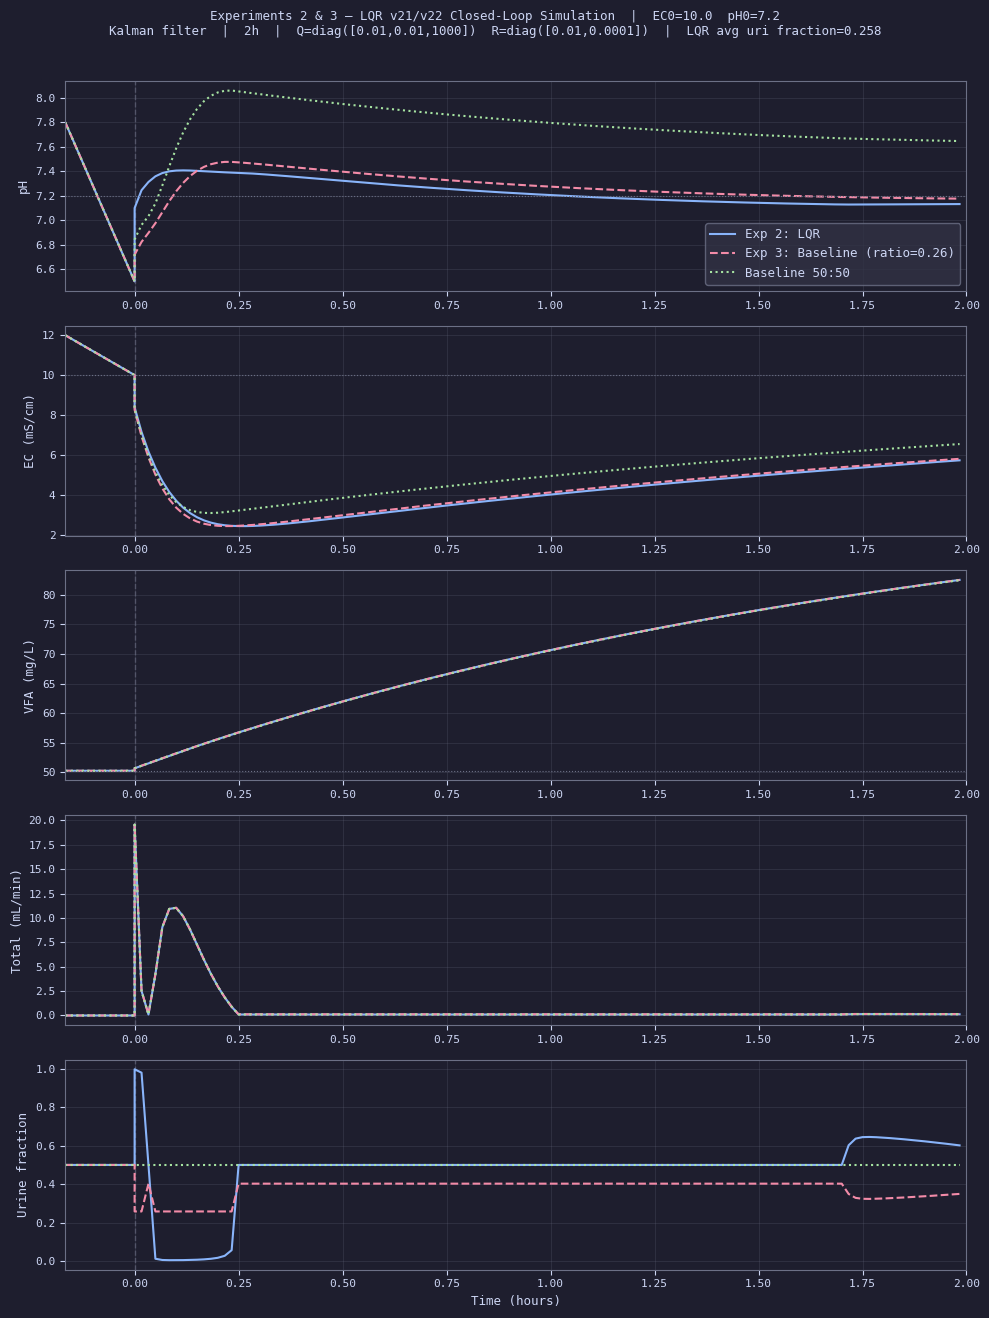

Saved: experiments_2_3_sim.png


In [2]:
BLUE='#89b4fa'; RED='#f38ba8'; GREEN='#a6e3a1'; GREY='#6c7086'; TEXT='#cdd6f4'
matplotlib.rcParams.update({
    'figure.facecolor':'#1e1e2e','axes.facecolor':'#1e1e2e',
    'text.color':TEXT,'axes.labelcolor':TEXT,
    'xtick.color':TEXT,'ytick.color':TEXT,
    'grid.color':GREY,'grid.linewidth':0.5,'font.family':'monospace'
})

panels = [('pH','pH',PH0),('EC','EC (mS/cm)',EC0),
          ('VFA','VFA (mg/L)',VFA0),('total','Total (mL/min)',None),('frac','Urine fraction',None)]

fig, axes = plt.subplots(5, 1, figsize=(10,13), facecolor='#1e1e2e')
fig.suptitle(
    f'Experiments 2 & 3 — LQR v21/v22 Closed-Loop Simulation  |  EC0=10.0  pH0=7.2\n'
    f'Kalman filter  |  2h  |  Q=diag([0.01,0.01,1000])  R=diag([0.01,0.0001])  |  LQR avg uri fraction={bl_frac:.3f}',
    color=TEXT, fontsize=9, y=1.01)

for row, (key, ylabel, setpt) in enumerate(panels):
    t1, y1 = prepend(lqr_hist,       key)
    t2, y2 = prepend(bl_ratio_hist,  key)
    t3, y3 = prepend(bl_5050_hist,   key)
    ax = axes[row]; ax.set_facecolor('#1e1e2e')
    for sp in ax.spines.values(): sp.set_color(GREY)
    ax.axvline(0, color=GREY, lw=1.0, linestyle='--', alpha=0.6)
    ax.plot(t1, y1, color=BLUE,  lw=1.5, label='Exp 2: LQR')
    ax.plot(t2, y2, color=RED,   lw=1.5, linestyle='--', label=f'Exp 3: Baseline (ratio={bl_frac:.2f})')
    ax.plot(t3, y3, color=GREEN, lw=1.5, linestyle=':',  label='Baseline 50:50')
    if setpt is not None: ax.axhline(setpt, color=GREY, lw=0.8, linestyle=':')
    ax.set_xlim(-PRE_STEPS/60, 2.0); ax.set_ylabel(ylabel, color=TEXT, fontsize=9)
    ax.grid(True, color=GREY, alpha=0.3); ax.tick_params(colors=TEXT, labelsize=8)
    if row==0: ax.legend(fontsize=9, facecolor='#313244', edgecolor=GREY, labelcolor=TEXT)

axes[-1].set_xlabel('Time (hours)', color=TEXT, fontsize=9)
plt.tight_layout()
plt.savefig('experiments_2_3_sim.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('Saved: experiments_2_3_sim.png')
